In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 14-1-2 程式範例：模板匹配

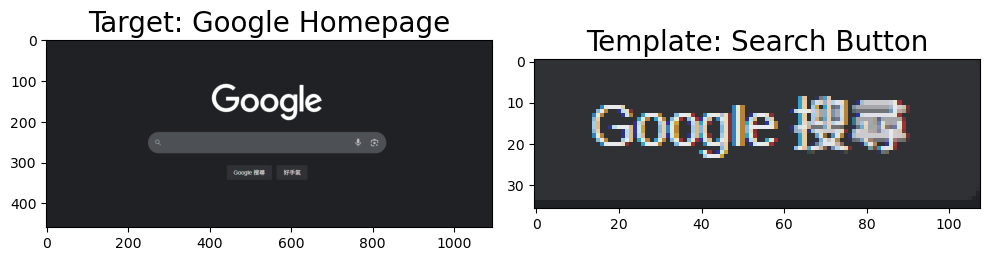

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2977308..0.9999995].


Matching Result (Heatmap)


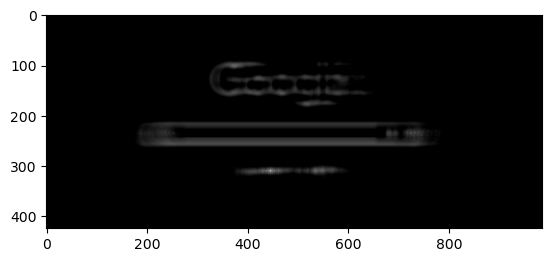

In [2]:
# 載入目標與模板影像
homepage_img = cv2.imread('sample/google_homepage.png')
button_template = cv2.imread('sample/google_search_button.png')

# 轉換為灰階（提升計算效率）
gray_homepage = cv2.cvtColor(homepage_img, cv2.COLOR_BGR2GRAY)
gray_button_template = cv2.cvtColor(button_template, cv2.COLOR_BGR2GRAY)

# 執行模板匹配
# TM_CCOEFF_NORMED 穩健易用，建議初學者優先選擇
match_heatmap = cv2.matchTemplate(gray_homepage, gray_button_template, cv2.TM_CCOEFF_NORMED)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Target: Google Homepage', homepage_img,
    'Template: Search Button', button_template
)

print('Matching Result (Heatmap)')
opencv_tools.show_img_by_matplotlib(match_heatmap)

### 14-1-4 程式範例：使用 cv2.minMaxLoc 找到匹配位置

最大相似度為：1.00


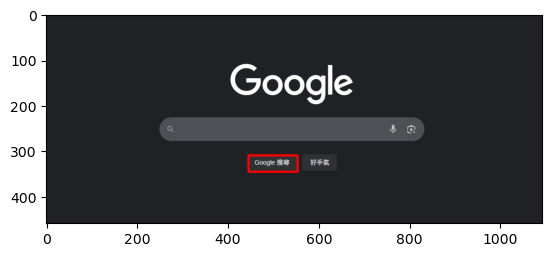

In [3]:
# （接續上一段程式碼，homepage_img、gray_button_template、match_heatmap 皆已存在）
# 解析結果，找出最匹配的位置
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(match_heatmap)
print(f"最大相似度為：{max_val:.2f}")

# 使用 TM_CCOEFF_NORMED，最亮點 max_loc 就是最佳匹配的左上角位置
top_left = max_loc

# 取得模板的寬高，計算右下角座標
h, w = gray_button_template.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

# 在原圖上標記結果
marked_homepage = homepage_img.copy()
cv2.rectangle(marked_homepage, top_left, bottom_right, (0, 0, 255), 3)

# 顯示標記後的結果
opencv_tools.show_img_by_matplotlib(marked_homepage)

### 14-2-1 程式範例：尋找所有高相似度的位置

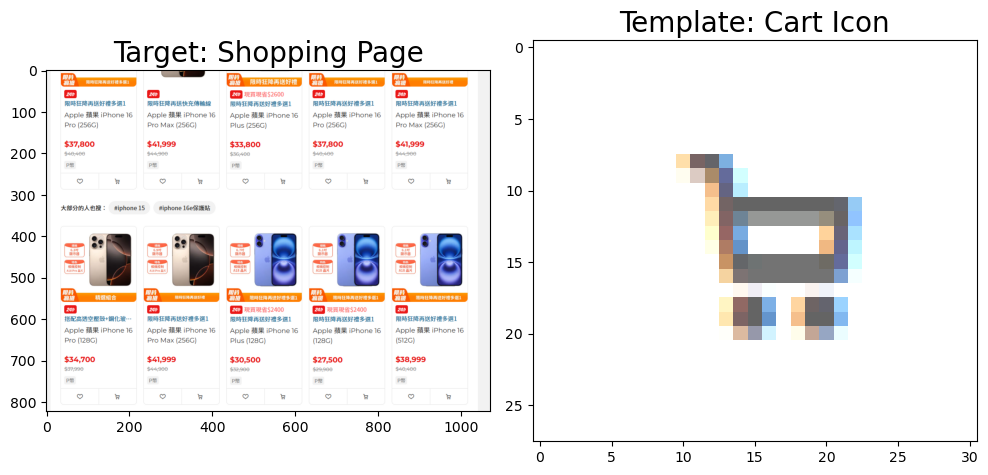

Result: 找到了 16 個相似度高於 0.8 的位置。


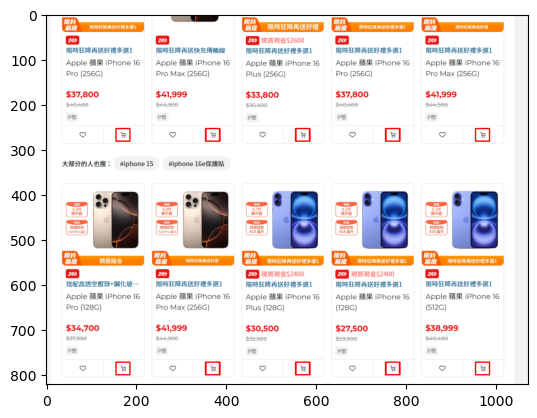

In [4]:
# 載入購物網站頁面與購物車模板
shopping_page = cv2.imread('sample/shopping_page.png')
cart_template = cv2.imread('sample/cart_icon.png')

# 灰階轉換與模板匹配
gray_shopping_page = cv2.cvtColor(shopping_page, cv2.COLOR_BGR2GRAY)
gray_cart_template = cv2.cvtColor(cart_template, cv2.COLOR_BGR2GRAY)
result = cv2.matchTemplate(gray_shopping_page, gray_cart_template, cv2.TM_CCOEFF_NORMED)

# 設定門檻值，找出所有匹配點
threshold = 0.8
locations = np.where(result >= threshold)
match_points = list(zip(locations[1], locations[0]))  # 轉換為 (x, y) 格式


# 在圖上標記所有找到的位置
page_with_all_matches = shopping_page.copy()
h, w = gray_cart_template.shape
for loc in match_points:
    top_left = loc
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv2.rectangle(page_with_all_matches, top_left, bottom_right, (0, 0, 255), 2)

# 顯示匹配結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Target: Shopping Page', shopping_page,
    'Template: Cart Icon', cart_template
)

print(f"Result: 找到了 {len(match_points)} 個相似度高於 {threshold} 的位置。")
opencv_tools.show_img_by_matplotlib(page_with_all_matches)

* 註：潛在問題：重疊的標記框

經過群組化處理後，剩下 10 個乾淨的目標。


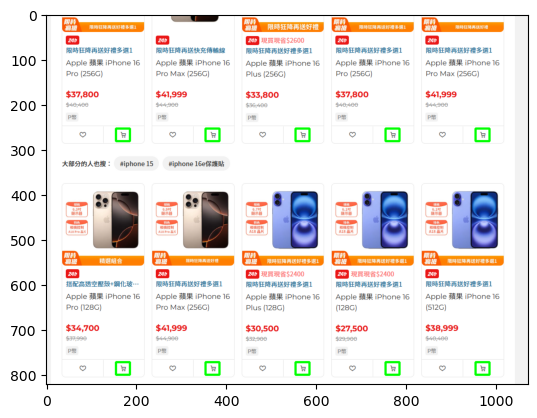

In [5]:
# (此處接續上一個程式碼區塊的 match_points)
# 進行處理重複標記前，我們需要先取得模板的寬高 (作為判斷重複的參考距離)
h, w = gray_cart_template.shape

# 存放最終結果的乾淨矩形框
clean_rects = []

# 當還有待處理的點時持續迴圈
while match_points:
    # 取出第一個點作為代表
    p = match_points.pop(0)
    rect = [p[0], p[1], w, h]
    clean_rects.append(rect)

    # 過濾掉與代表點距離太近的其他點
    remaining_points = []
    for other_p in match_points:
        dist_x = abs(p[0] - other_p[0])
        dist_y = abs(p[1] - other_p[1])
        # X 或 Y 距離大於模板尺寸的一半，才算是不同目標
        if dist_x > w / 2 or dist_y > h / 2:
            remaining_points.append(other_p)
    match_points = remaining_points

# 在圖上標記乾淨的結果
page_with_clean_matches = shopping_page.copy()
for rect in clean_rects:
    top_left = (rect[0], rect[1])
    bottom_right = (rect[0] + rect[2], rect[1] + rect[3])
    cv2.rectangle(page_with_clean_matches, top_left, bottom_right, (0, 255, 0), 3)

print(f"經過群組化處理後，剩下 {len(clean_rects)} 個乾淨的目標。")
opencv_tools.show_img_by_matplotlib(page_with_clean_matches)

## 14-E 小專案：找到影片畫面中的「略過廣告」按鈕

最大相似度為：1.00


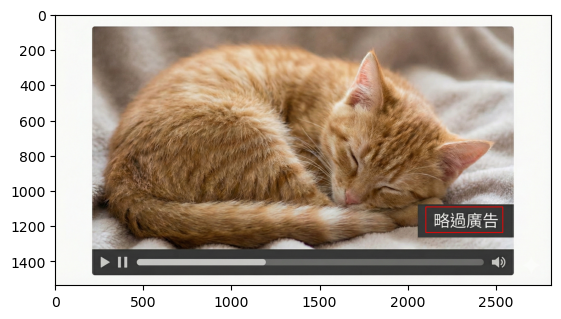

In [6]:
# 載入目標與模板影像
video_frame = cv2.imread('sample/fake_yt_with_ad.png')
skip_ad_template = cv2.imread('sample/fake_ad_skip.png')

# 轉換為灰階（提升計算效率）
gray_video_frame = cv2.cvtColor(video_frame, cv2.COLOR_BGR2GRAY)
gray_skip_ad_template = cv2.cvtColor(skip_ad_template, cv2.COLOR_BGR2GRAY)

# 執行模板匹配
# TM_CCOEFF_NORMED 穩健易用，建議初學者優先選擇
result = cv2.matchTemplate(gray_video_frame, gray_skip_ad_template, cv2.TM_CCOEFF_NORMED)

# 解析結果，找出最匹配的位置
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
print(f"最大相似度為：{max_val:.2f}")

# 使用 TM_CCOEFF_NORMED，最亮點 max_loc 就是最佳匹配的左上角位置
top_left = max_loc

# 取得模板的寬高，計算右下角座標
h, w, c = skip_ad_template.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

# 在原圖上標記結果
video_frame_copy = video_frame.copy()
cv2.rectangle(video_frame_copy, top_left, bottom_right, (0, 0, 255), 3)

# 顯示結果
opencv_tools.show_img_by_matplotlib(video_frame_copy)